# G1/G2/G3 Generation Consistency

This experiment measures repeated **generation**, not repeated OpenAI judgments. Five independent generation calls per reflection and condition produce assessment scores for SW, UA, and HA. G2 uses frozen saved GBERT predictions; G3 uses frozen observed human candidate annotations, not an oracle. Teacher feedback and gold summaries are never sent to the generation model.

The 22 reference-complete reflections are separated into four playground documents and 18 test documents. First validate the protocol on playground, then explicitly freeze it before enabling test. The source test split remains unchanged. All 330 successful calls (60 playground, 270 test) are fresh repetitions; retries add attempts. Re-running the runner resumes missing calls, not new independent repetitions.

## Measurement policy

Existing assessments return decimal scores 0.0-3.0. The default evaluates exact decimal categories without treating numeric distances as equal. Nominal alpha is the primary chance-corrected metric for this policy; ordinal alpha is supplementary. For categorical-band analysis, supply a complete rubric-grounded mapping for every decimal score **before calls**. No rounding or band thresholds are invented. Changing the mapping or protocol creates a different experiment fingerprint.

Pairwise exact agreement and unanimous consistency are reported per condition/dimension. Alpha uses repetition rounds as raters and reflections as units. Primary estimates require all five repetitions; missing units and failures remain explicit. Undefined alpha (e.g. no category variation) is not replaced with 0 or 1. Cross-condition agreement uses all repetition combinations, not arbitrary round pairing. Author-cluster bootstrap intervals for paired repeatability differences are exploratory, and unavailable for fewer than two author clusters.

Full outputs, reflections, annotations, per-document diagnostics, and attempt records stay in approved protected storage. Notebook displays are aggregate-only. Stability does not establish correctness. Provider calls and LangSmith traces may contain complete reflections. Calls are disabled by default.

In [1]:
import hashlib
import json
import os
from pathlib import Path
from datetime import datetime, timezone
from itertools import product
from uuid import uuid4

import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

from reflection_assessment_feedback import EXPERT_RUBRIC
from reflection_assessment_feedback.data import load_human_analysis_context, make_generation_request
from reflection_assessment_feedback.development_cohorts import load_author_document_group
from reflection_assessment_feedback.experiment_config import load_experiment_config, experiment_config_sha256
from reflection_assessment_feedback.models import GenerationRequest, GenerationOutput, IntermediateAnalysis
from reflection_assessment_feedback.generator import RubricGenerationRunner, validate_output
from reflection_assessment_feedback.prompt import build_prompt, prompt_components_for_request
from reflection_assessment_feedback.generation_consistency import consistency_tables, paired_consistency_differences

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'config' / 'experiment.toml').is_file():
    raise RuntimeError('Run from the prebi_v1 project root.')
load_dotenv(PROJECT_ROOT / '.env', override=False)
protected_value = os.getenv('PREBI_DATA_ROOT')
if not protected_value:
    raise RuntimeError('Set PREBI_DATA_ROOT to approved protected storage.')
PROTECTED_ROOT = Path(protected_value).expanduser().resolve()
if PROTECTED_ROOT == PROJECT_ROOT or PROJECT_ROOT in PROTECTED_ROOT.parents:
    raise ValueError('Protected storage must be outside the source tree.')
CONFIG = load_experiment_config()
GENERATION_CONFIG = CONFIG['generation']
SPLIT_DIRECTORY = PROJECT_ROOT / CONFIG['paths']['provisional_split_directory']

EXPERIMENT_TAG = 'generation-consistency-v1'
REPETITIONS = 5
MAX_ATTEMPTS = 3
CATEGORY_POLICY = 'exact_decimal'
BAND_MAPPING = None
BAND_MAPPING_RATIONALE = ''
MODES_TO_RUN = ('playground',)
RUN_GENERATION = False
APPROVE_EXTERNAL_PROCESSING = False
APPROVE_CATEGORY_POLICY = False
APPROVE_G2_PROVENANCE = False
PROTOCOL_FROZEN_FOR_TEST = False
ENABLE_LANGSMITH_TRACING = bool(GENERATION_CONFIG['enable_langsmith_tracing'])
SAVE_ANALYSIS = False
BOOTSTRAP_SAMPLES = 2000
BOOTSTRAP_SEED = int(CONFIG['evaluation']['random_seed'])

if REPETITIONS < 2 or MAX_ATTEMPTS < 1:
    raise ValueError('Invalid repetition or attempt count.')
if CATEGORY_POLICY not in {'exact_decimal', 'categorical_bands'}:
    raise ValueError('Choose exact_decimal or categorical_bands.')
if CATEGORY_POLICY == 'categorical_bands':
    from reflection_assessment_feedback.generation_consistency import encode_score
    if not BAND_MAPPING or not BAND_MAPPING_RATIONALE.strip():
        raise ValueError('Supply a complete rubric-grounded mapping and its rationale; do not round arbitrarily.')
    mapped = [encode_score(step / 10, BAND_MAPPING) for step in range(31)]
    if mapped != sorted(mapped, key=int):
        raise ValueError('Band mapping must preserve score order.')
elif BAND_MAPPING is not None:
    raise ValueError('Exact-decimal policy must not apply a band mapping.')
if not MODES_TO_RUN or not set(MODES_TO_RUN).issubset({'playground', 'test'}):
    raise ValueError('Choose playground and/or test modes.')

def canonical_hash(value):
    return hashlib.sha256(json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(',', ':')).encode()).hexdigest()

print('Consistency setup loaded; provider generation disabled unless explicitly approved.')
print('Category policy:', CATEGORY_POLICY, '; repetitions:', REPETITIONS)

Consistency setup loaded; provider generation disabled unless explicitly approved.
Category policy: exact_decimal ; repetitions: 5


## Frozen inputs and cohort preflight

The packet keys identify the reference-complete cohort; existing generated outputs are not reused as repetitions. Reflection snapshots are checked against the canonical test export. G2 files are validated for source and exact segment coverage, then their file hashes and original provenance are frozen. Older config hashes and absent checkpoint fingerprints are surfaced for review, not rewritten. The runner uses the frozen request snapshots after this preflight.

In [2]:
manifest_path = SPLIT_DIRECTORY / 'provisional_split_manifest.csv'
manifest = pd.read_csv(manifest_path, dtype={'document_id': str, 'author_id': str, 'split': str})
playground_ids = set(load_author_document_group(
    manifest_path, str(CONFIG['dataset']['exploratory_document_id']),
)['document_id'])
packet_directory = PROTECTED_ROOT / 'rating-packets' / 'development'
prefixes = ['r1', CONFIG['dataset']['generation_cohort'].lower().replace('_', '-')]
reference_ids = set()
reflection_snapshots = {}
packet_hashes = {}
for prefix in prefixes:
    key_path = packet_directory / f'{prefix}-condition-key.json'
    bundle_path = packet_directory / f'{prefix}-rating-packets.json'
    packet_hashes[prefix] = {'key': hashlib.sha256(key_path.read_bytes()).hexdigest(),
                             'bundle': hashlib.sha256(bundle_path.read_bytes()).hexdigest()}
    key = json.loads(key_path.read_text())
    bundle = json.loads(bundle_path.read_text())
    key_records = {row['packet_id']: row for row in key['records']}
    for packet in bundle['packets']:
        if packet['task'] not in {'assessment_quality', 'feedback_quality', 'feedback_implied_score'}:
            continue
        document_id = str(key_records[packet['packet_id']]['document_id'])
        if packet['task'] == 'feedback_implied_score':
            if not packet.get('human_feedback', '').strip():
                raise ValueError('Reference-complete selection requires teacher feedback.')
            reference_ids.add(document_id)
        else:
            snapshot = canonical_hash(packet['reflection']['segments'])
            if reflection_snapshots.setdefault(document_id, snapshot) != snapshot:
                raise ValueError('Packets disagree on reflection text or order.')
if len(reference_ids) != 22 or reference_ids != set(reflection_snapshots):
    raise ValueError('Expected 22 reference-complete packet documents.')
if not playground_ids.issubset(reference_ids):
    raise ValueError('Playground documents must have complete reference packets.')
cohort_units = manifest.loc[manifest['document_id'].isin(reference_ids), ['document_id', 'author_id', 'split']].copy()
if cohort_units.document_id.duplicated().any() or not cohort_units['split'].eq('test').all():
    raise ValueError('Cohort must contain unique test documents.')
cohort_units['mode'] = cohort_units.document_id.map(lambda document_id: 'playground' if document_id in playground_ids else 'test')
cohort_units = cohort_units.sort_values('document_id').reset_index(drop=True)
request_snapshots = {}
input_provenance = {}
g2_old_config_documents = 0
g2_without_checkpoint_fingerprint = 0
for document_id in cohort_units.document_id:
    document, human_context = load_human_analysis_context(
        SPLIT_DIRECTORY / 'provisional_test_modeling_wide.csv', document_id,
    )
    if canonical_hash([segment.model_dump(mode='json') for segment in document.segments]) != reflection_snapshots[document_id]:
        raise ValueError('Canonical reflection differs from the packet snapshot.')
    prediction_path = PROTECTED_ROOT / 'g2' / 'predictions' / f'predicted-analysis-{document_id}.json'
    package = json.loads(prediction_path.read_text())
    if str(package['document_id']) != document_id:
        raise ValueError('G2 file has the wrong document ID.')
    predicted = IntermediateAnalysis.model_validate(package['analysis'])
    if predicted.source != 'predicted':
        raise ValueError('G2 must use predicted analysis, not human analysis.')
    g2_old_config_documents += package.get('experiment_config_sha256') != experiment_config_sha256()
    g2_without_checkpoint_fingerprint += not bool(package.get('classifier_model_sha256') or package.get('checkpoint_sha256'))
    input_provenance[document_id] = {
        'document_sha256': canonical_hash(document.model_dump(mode='json')),
        'human_analysis_sha256': canonical_hash(human_context.model_dump(mode='json')),
        'prediction_file_sha256': hashlib.sha256(prediction_path.read_bytes()).hexdigest(),
        'original_prediction_config_sha256': package.get('experiment_config_sha256'),
    }
    for condition, analysis in (('G1', None), ('G2', predicted), ('G3', human_context)):
        request = make_generation_request(condition=condition, document=document, rubric=EXPERT_RUBRIC, analysis=analysis)
        request_snapshots[(document_id, condition)] = request.model_dump(mode='json')

protocol = {
    'experiment_tag': EXPERIMENT_TAG, 'repetitions': REPETITIONS, 'maximum_attempts': MAX_ATTEMPTS,
    'conditions': ['G1', 'G2', 'G3'], 'category_policy': CATEGORY_POLICY,
    'band_mapping': BAND_MAPPING, 'band_mapping_rationale': BAND_MAPPING_RATIONALE,
    'generation_config': GENERATION_CONFIG, 'tracing_enabled': ENABLE_LANGSMITH_TRACING,
    'experiment_config_sha256': experiment_config_sha256(),
    'cohort': cohort_units.to_dict(orient='records'), 'packet_hashes': packet_hashes,
    'input_provenance': input_provenance,
    'request_hashes': {f'{document_id}:{condition}': canonical_hash(snapshot)
                       for (document_id, condition), snapshot in request_snapshots.items()},
    'prompt_hashes': {f'{document_id}:{condition}': hashlib.sha256(build_prompt(
        GenerationRequest.model_validate(snapshot)
    ).encode()).hexdigest() for (document_id, condition), snapshot in request_snapshots.items()},
    'prompt_components': {
        condition: [{'id': artifact.artifact_id, 'version': artifact.version, 'sha256': artifact.sha256}
                    for artifact in prompt_components_for_request(GenerationRequest.model_validate(
                        request_snapshots[(cohort_units.document_id.iloc[0], condition)]
                    ))] for condition in ('G1', 'G2', 'G3')
    },
    'ordering': 'repetition rounds; document order rotated; condition order rotated by round and document',
    'analysis_policy': 'complete units primary; missing values reported; no imputation',
    'implementation_hashes': {
        filename: hashlib.sha256((PROJECT_ROOT / 'reflection_assessment_feedback' / filename).read_bytes()).hexdigest()
        for filename in ('generator.py', 'prompt.py', 'generation_consistency.py')
    },
}
protocol_hash = canonical_hash(protocol)
EXPERIMENT_DIRECTORY = PROTECTED_ROOT / 'generation-consistency' / protocol_hash
if not EXPERIMENT_DIRECTORY.resolve().is_relative_to(PROTECTED_ROOT):
    raise ValueError('Experiment directory must resolve within protected storage.')
print('Frozen protocol fingerprint:', protocol_hash)
display(cohort_units.groupby('mode').size().rename('documents').to_frame().assign(
    successful_calls=lambda table: table.documents * REPETITIONS * 3,
))
print('G2 artifacts with older config hashes:', g2_old_config_documents)
print('G2 artifacts without checkpoint fingerprints:', g2_without_checkpoint_fingerprint)
print('G2 artifacts are fixed inputs, not proof of checkpoint identity. Review them before setting APPROVE_G2_PROVENANCE.')

Frozen protocol fingerprint: 17206b4b3a6d4d5d77d32f58e9a14b6db5e3119c6c8bf5bd5ce5a785ab451321


,documents,successful_calls
mode,,
playground,4,60
test,18,270


G2 artifacts with older config hashes: 22
G2 artifacts without checkpoint fingerprints: 22
G2 artifacts are fixed inputs, not proof of checkpoint identity. Review them before setting APPROVE_G2_PROVENANCE.


In [3]:
if MODES_TO_RUN != ('playground',) or CATEGORY_POLICY != 'exact_decimal' or REPETITIONS != 5:
    raise RuntimeError('This execution approval is limited to the five-repetition exact-decimal playground pilot.')
if canonical_hash(protocol) != protocol_hash:
    raise ValueError('Protocol changed after preflight.')
RUN_GENERATION = True
APPROVE_EXTERNAL_PROCESSING = True
APPROVE_CATEGORY_POLICY = True
APPROVE_G2_PROVENANCE = True
PROTOCOL_FROZEN_FOR_TEST = False
SAVE_ANALYSIS = True
print('Authorized playground only: 60 successful calls, exact decimal categories, frozen saved G2 labels.')
print('Test generation remains disabled; older G2 config provenance is retained, not rewritten.')

Authorized playground only: 60 successful calls, exact decimal categories, frozen saved G2 labels.
Test generation remains disabled; older G2 config provenance is retained, not rewritten.


In [4]:
if CATEGORY_POLICY != 'exact_decimal' or REPETITIONS != 5 or BAND_MAPPING is not None:
    raise RuntimeError('Test approval is limited to the unchanged five-repetition exact-decimal protocol.')
if canonical_hash(protocol) != protocol_hash:
    raise ValueError('Protocol changed after playground preflight.')
if json.loads((EXPERIMENT_DIRECTORY / 'protocol.json').read_text()) != protocol:
    raise ValueError('Saved playground protocol differs from the current protocol.')
if experiment_config_sha256() != protocol['experiment_config_sha256']:
    raise ValueError('Experiment configuration changed since playground generation.')
for filename, expected_hash in protocol['implementation_hashes'].items():
    if hashlib.sha256((PROJECT_ROOT / 'reflection_assessment_feedback' / filename).read_bytes()).hexdigest() != expected_hash:
        raise ValueError('Implementation changed since playground generation.')
for (document_id, condition), snapshot in request_snapshots.items():
    if canonical_hash(snapshot) != protocol['request_hashes'][f'{document_id}:{condition}']:
        raise ValueError('Frozen input snapshot changed.')
    if hashlib.sha256(build_prompt(GenerationRequest.model_validate(snapshot)).encode()).hexdigest() != protocol['prompt_hashes'][f'{document_id}:{condition}']:
        raise ValueError('Rendered prompt changed since playground generation.')
MODES_TO_RUN = ('test',)
RUN_GENERATION = True
APPROVE_EXTERNAL_PROCESSING = True
APPROVE_CATEGORY_POLICY = True
APPROVE_G2_PROVENANCE = True
PROTOCOL_FROZEN_FOR_TEST = True
SAVE_ANALYSIS = True
print('Unchanged protocol authorized for 18 non-playground test reflections: 270 successful generation calls.')
print('Playground results remain separate and will not be regenerated.')

Unchanged protocol authorized for 18 non-playground test reflections: 270 successful generation calls.
Playground results remain separate and will not be regenerated.


## Generate independent repetitions

Set `RUN_GENERATION`, the three approval switches, and (for test) `PROTOCOL_FROZEN_FOR_TEST` explicitly in setup. Playground is the default mode. The same protocol fingerprint is shared by both modes; the mode selection only controls which missing calls execute. Existing G1/G2/G3 outputs are never counted as fresh repetitions.

Each cell/repetition has a stable key, immutable validated result, and separate attempt records. Interrupted attempts are counted against the limit rather than silently retried indefinitely. An exclusive lock prevents concurrent runners. Failed calls are not fabricated or imputed. Completed repetitions are reused only for resumption. The configured model may ignore temperature; requested and observed client parameters are recorded, and provider warnings should be retained. This uses the generation provider (Google Gemini), not the OpenAI judge.

In [5]:
import fcntl
import tempfile
from dataclasses import asdict
from langchain_core.exceptions import OutputParserException
from pydantic import ValidationError
from reflection_assessment_feedback.rate_limit import reserve_request_slot


def write_private_json(path, content):
    path.parent.mkdir(parents=True, exist_ok=True, mode=0o700)
    path.parent.chmod(0o700)
    temporary_path = None
    try:
        with tempfile.NamedTemporaryFile(mode='w', encoding='utf-8', dir=path.parent, delete=False) as handle:
            temporary_path = Path(handle.name)
            json.dump(content, handle, ensure_ascii=False, indent=2, allow_nan=False)
        temporary_path.chmod(0o600)
        os.link(temporary_path, path)
    finally:
        if temporary_path is not None:
            temporary_path.unlink(missing_ok=True)


def repetition_key(document_id, condition, repetition):
    return f'{hashlib.sha256(document_id.encode()).hexdigest()[:20]}-{condition}-{repetition}'


def validate_saved_record(record, document_id, condition, repetition):
    expected = {
        'protocol_sha256': protocol_hash, 'document_id': document_id,
        'condition': condition, 'repetition': repetition,
        'request_sha256': protocol['request_hashes'][f'{document_id}:{condition}'],
        'prompt_sha256': protocol['prompt_hashes'][f'{document_id}:{condition}'],
    }
    if any(record.get(key) != value for key, value in expected.items()):
        raise ValueError('Saved repetition conflicts with the frozen protocol or inputs.')
    request = GenerationRequest.model_validate(request_snapshots[(document_id, condition)])
    output = GenerationOutput.model_validate(record['output'])
    validate_output(request, output)
    dimensions = [item.dimension_id for item in output.assessment.component_assessments]
    if set(dimensions) != {'SW', 'UA', 'HA'} or len(dimensions) != 3:
        raise ValueError('Each repetition must assess exactly SW, UA, and HA.')
    return output


if not RUN_GENERATION:
    print('Provider calls disabled. Preflight and analysis can run independently.')
else:
    if not (APPROVE_EXTERNAL_PROCESSING and APPROVE_CATEGORY_POLICY and APPROVE_G2_PROVENANCE):
        raise RuntimeError('Approve external processing, category policy, and frozen G2 provenance first.')
    if 'test' in MODES_TO_RUN and not PROTOCOL_FROZEN_FOR_TEST:
        raise RuntimeError('Freeze the protocol after playground validation before enabling test.')
    if GENERATION_CONFIG['provider'] != 'google':
        raise ValueError('This runner currently supports the configured Google adapter only.')
    if not (os.getenv('GOOGLE_API_KEY') or os.getenv('GEMINI_API_KEY')):
        raise RuntimeError('Configure Google credentials directly in the approved environment.')
    if ENABLE_LANGSMITH_TRACING:
        if not os.getenv('LANGSMITH_API_KEY') or not os.getenv('LANGSMITH_PROJECT'):
            raise RuntimeError('Approved LangSmith credentials and project are required.')
        if os.getenv('LANGSMITH_ENDPOINT', 'https://eu.api.smith.langchain.com').rstrip('/') != 'https://eu.api.smith.langchain.com':
            raise ValueError('Tracing requires the approved EU endpoint.')
    if canonical_hash(protocol) != protocol_hash:
        raise ValueError('Protocol changed after preflight.')
    EXPERIMENT_DIRECTORY.mkdir(parents=True, exist_ok=True, mode=0o700)
    EXPERIMENT_DIRECTORY.chmod(0o700)
    lock_descriptor = os.open(EXPERIMENT_DIRECTORY / '.runner.lock', os.O_CREAT | os.O_RDWR, 0o600)
    with os.fdopen(lock_descriptor, 'w') as lock:
        fcntl.flock(lock.fileno(), fcntl.LOCK_EX | fcntl.LOCK_NB)
        protocol_path = EXPERIMENT_DIRECTORY / 'protocol.json'
        if protocol_path.exists():
            if json.loads(protocol_path.read_text()) != protocol:
                raise ValueError('Existing protocol manifest differs.')
        else:
            write_private_json(protocol_path, protocol)
        for (document_id, condition), snapshot in request_snapshots.items():
            if canonical_hash(snapshot) != protocol['request_hashes'][f'{document_id}:{condition}']:
                raise ValueError('Request snapshot changed after preflight.')
            request_path = EXPERIMENT_DIRECTORY / 'inputs' / f'{repetition_key(document_id, condition, 0)}.json'
            if request_path.exists():
                if json.loads(request_path.read_text()) != snapshot:
                    raise ValueError('Frozen input snapshot differs.')
            else:
                write_private_json(request_path, snapshot)
        from langchain_google_genai import ChatGoogleGenerativeAI
        generation_model = ChatGoogleGenerativeAI(
            model=GENERATION_CONFIG['model_name'], temperature=GENERATION_CONFIG['temperature'],
        )
        runner = RubricGenerationRunner(generation_model, enable_langsmith_tracing=ENABLE_LANGSMITH_TRACING)
        generation_counts = {'new_results': 0, 'resumed_results': 0, 'failed_or_exhausted': 0, 'provider_attempts': 0}
        selected_units = cohort_units.loc[cohort_units['mode'].isin(MODES_TO_RUN)]
        conditions = ['G1', 'G2', 'G3']
        document_ids = selected_units.document_id.tolist()
        for repetition in range(1, REPETITIONS + 1):
            rotation = (repetition - 1) % len(document_ids)
            ordered_documents = document_ids[rotation:] + document_ids[:rotation]
            for document_number, document_id in enumerate(ordered_documents):
                shift = (repetition - 1 + document_number) % 3
                for condition in conditions[shift:] + conditions[:shift]:
                    key = repetition_key(document_id, condition, repetition)
                    result_path = EXPERIMENT_DIRECTORY / 'results' / f'{key}.json'
                    if result_path.exists():
                        validate_saved_record(json.loads(result_path.read_text()), document_id, condition, repetition)
                        generation_counts['resumed_results'] += 1
                        continue
                    request = GenerationRequest.model_validate(request_snapshots[(document_id, condition)])
                    if hashlib.sha256(build_prompt(request).encode()).hexdigest() != protocol['prompt_hashes'][f'{document_id}:{condition}']:
                        raise ValueError('Rendered prompt changed after preflight.')
                    base_record = {
                        'protocol_sha256': protocol_hash, 'document_id': document_id,
                        'condition': condition, 'repetition': repetition,
                        'request_sha256': protocol['request_hashes'][f'{document_id}:{condition}'],
                        'prompt_sha256': protocol['prompt_hashes'][f'{document_id}:{condition}'],
                    }
                    attempt_directory = EXPERIMENT_DIRECTORY / 'attempts' / key
                    existing = list(attempt_directory.glob('started-*.json')) if attempt_directory.exists() else []
                    start_attempt = max([int(path.stem.split('-')[-1]) for path in existing], default=0) + 1
                    succeeded = False
                    for attempt in range(start_attempt, MAX_ATTEMPTS + 1):
                        attempt_record = {**base_record, 'attempt': attempt, 'attempt_id': str(uuid4()),
                                          'started_at': datetime.now(timezone.utc).isoformat()}
                        write_private_json(attempt_directory / f'started-{attempt}.json', attempt_record)
                        reserve_request_slot(PROTECTED_ROOT / '.rate_limits' / 'gemini.state',
                                             GENERATION_CONFIG['minimum_request_interval_seconds'])
                        generation_counts['provider_attempts'] += 1
                        try:
                            run = runner.generate(request, repetition=repetition)
                            payload = {**base_record, 'attempt': attempt, 'run': asdict(run),
                                       'output': run.output.model_dump(mode='json')}
                            payload['run']['output'] = payload['output']
                            validate_saved_record(payload, document_id, condition, repetition)
                        except Exception as error:
                            write_private_json(attempt_directory / f'failed-{attempt}.json', {
                                **attempt_record, 'finished_at': datetime.now(timezone.utc).isoformat(),
                                'error_type': type(error).__name__, 'message': str(error),
                            })
                            if not isinstance(error, (OutputParserException, ValidationError, ValueError)):
                                raise
                            print(f'Repetition {repetition}, {condition}: invalid output attempt {attempt}; details protected.', flush=True)
                            continue
                        write_private_json(result_path, payload)
                        write_private_json(attempt_directory / f'succeeded-{attempt}.json', {
                            **attempt_record, 'finished_at': datetime.now(timezone.utc).isoformat(),
                        })
                        succeeded = True
                        generation_counts['new_results'] += 1
                        break
                    if not succeeded:
                        generation_counts['failed_or_exhausted'] += 1
                    print(f'Round {repetition}/{REPETITIONS}, document {document_number + 1}/{len(document_ids)}, '
                          f'{condition}: {"saved" if succeeded else "missing/exhausted"}.', flush=True)
        print('Generation invocation counts:', generation_counts)

Round 5/5, document 12/18, G2: missing/exhausted.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Round 5/5, document 12/18, G3: saved.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Round 5/5, document 13/18, G2: saved.


...

Round 5/5, document 18/18, G1: saved.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Round 5/5, document 18/18, G2: saved.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Round 5/5, document 18/18, G3: saved.
Generation invocation counts: {'new_results': 19, 'resumed_results': 250, 'failed_or_exhausted': 1, 'provider_attempts': 19}


## Coverage, failures, and agreement analysis

This section never calls a provider. Saved results are revalidated against the frozen inputs and prompt fingerprints. Missing repetitions are not imputed, and incomplete reflections are excluded from primary agreement estimates. Failed and interrupted attempts are reported separately from successful result counts. Changing modes does not pool playground and test.

The plots use aggregate agreement and category frequencies only. Exact decimal categories are not rubric bands. Optional exports include protected per-document diagnostics and aggregate metrics. Bootstrap intervals are descriptive/exploratory with few author groups.

In [15]:
score_rows = []
result_paths = list((EXPERIMENT_DIRECTORY / 'results').glob('*.json'))
observed_calls = set()
if result_paths:
    if json.loads((EXPERIMENT_DIRECTORY / 'protocol.json').read_text()) != protocol:
        raise ValueError('Stored experiment manifest differs from the current preflight.')
for path in result_paths:
    record = json.loads(path.read_text())
    document_id, condition, repetition = record['document_id'], record['condition'], record['repetition']
    if (document_id, condition) not in request_snapshots or repetition not in range(1, REPETITIONS + 1):
        raise ValueError('Saved result lies outside the frozen cohort/protocol.')
    if (document_id, condition, repetition) in observed_calls:
        raise ValueError('Duplicate independent-call key.')
    observed_calls.add((document_id, condition, repetition))
    output = validate_saved_record(record, document_id, condition, repetition)
    for assessment in output.assessment.component_assessments:
        score_rows.append({'document_id': document_id, 'condition': condition,
                           'repetition': repetition, 'dimension_id': assessment.dimension_id,
                           'score': assessment.band})
scores = pd.DataFrame(score_rows, columns=['document_id', 'condition', 'repetition', 'dimension_id', 'score'])
coverage_rows = []
for mode, units in cohort_units.groupby('mode'):
    valid_calls = sum(document_id in set(units.document_id) for document_id, _, _ in observed_calls)
    expected_calls = len(units) * 3 * REPETITIONS
    coverage_rows.append({'mode': mode, 'expected_calls': expected_calls, 'successful_calls': valid_calls,
                          'missing_calls': expected_calls - valid_calls})
coverage = pd.DataFrame(coverage_rows)
started_attempts = list((EXPERIMENT_DIRECTORY / 'attempts').glob('*/started-*.json'))
failed_attempts = list((EXPERIMENT_DIRECTORY / 'attempts').glob('*/failed-*.json'))
succeeded_attempts = list((EXPERIMENT_DIRECTORY / 'attempts').glob('*/succeeded-*.json'))
attempt_audit = {'started_attempts': len(started_attempts), 'failed_attempts': len(failed_attempts),
                 'succeeded_attempt_records': len(succeeded_attempts),
                 'unfinished_attempt_records': len(started_attempts) - len(failed_attempts) - len(succeeded_attempts)}
display(coverage)
print('Attempt audit:', attempt_audit)
print('Category policy:', CATEGORY_POLICY)
consistency_results = consistency_tables(
    scores, units=cohort_units[['document_id', 'mode', 'author_id']],
    repetitions=REPETITIONS, band_mapping=BAND_MAPPING,
)
consistency_results['paired_differences'] = paired_consistency_differences(
    consistency_results['per_document'], samples=BOOTSTRAP_SAMPLES, seed=BOOTSTRAP_SEED,
)
display(consistency_results['within'].round(4))
display(consistency_results['between'].round(4))
display(consistency_results['paired_differences'].round(4))
if scores.empty:
    print('No generation repetitions saved yet; coverage is zero and agreement metrics are undefined.')

,mode,expected_calls,successful_calls,missing_calls
0,playground,60,60,0
1,test,270,270,0


Attempt audit: {'started_attempts': 342, 'failed_attempts': 11, 'succeeded_attempt_records': 330, 'unfinished_attempt_records': 1}
Category policy: exact_decimal


,mode,condition,dimension_id,documents,complete_documents,missing_ratings,pairwise_exact,unanimous_rate,alpha_nominal,alpha_nominal_status,alpha_ordinal,alpha_ordinal_status
0,playground,G1,SW,4,4,0,0.9000,0.7500,0.7031,defined,0.7031,defined
1,playground,G2,SW,4,4,0,0.5750,0.2500,0.3271,defined,0.5469,defined
2,playground,G3,SW,4,4,0,0.7500,0.5000,0.6481,defined,0.9742,defined
3,playground,G1,UA,4,4,0,0.7250,0.5000,0.6214,defined,0.7137,defined
4,playground,G2,UA,4,4,0,0.2250,0.0000,0.1287,defined,0.7608,defined
5,playground,G3,UA,4,4,0,0.4500,0.0000,0.2316,defined,0.6000,defined
6,playground,G1,HA,4,4,0,0.6000,0.0000,0.4899,defined,0.9062,defined
7,playground,G2,HA,4,4,0,0.3250,0.2500,0.2587,defined,0.7167,defined
8,playground,G3,HA,4,4,0,0.3000,0.0000,0.1939,defined,0.8029,defined
9,test,G1,SW,18,18,0,0.7944,0.6667,0.7058,defined,0.9461,defined


,mode,dimension_id,left,right,complete_documents,all_pairs_exact
0,playground,SW,G1,G2,4,0.0500
1,playground,SW,G1,G3,4,0.6200
2,playground,SW,G2,G3,4,0.1300
3,playground,UA,G1,G2,4,0.1700
4,playground,UA,G1,G3,4,0.1100
5,playground,UA,G2,G3,4,0.1100
6,playground,HA,G1,G2,4,0.0000
7,playground,HA,G1,G3,4,0.1700
8,playground,HA,G2,G3,4,0.0000
9,test,SW,G1,G2,18,0.1289


,mode,dimension_id,contrast,documents,authors,difference,lower_95,upper_95,interval_status
0,playground,HA,G2_minus_G1,4,1,-0.2750,NaN,NaN,insufficient_author_clusters
1,playground,HA,G3_minus_G1,4,1,-0.3000,NaN,NaN,insufficient_author_clusters
2,playground,HA,G3_minus_G2,4,1,-0.0250,NaN,NaN,insufficient_author_clusters
3,playground,SW,G2_minus_G1,4,1,-0.3250,NaN,NaN,insufficient_author_clusters
4,playground,SW,G3_minus_G1,4,1,-0.1500,NaN,NaN,insufficient_author_clusters
5,playground,SW,G3_minus_G2,4,1,0.1750,NaN,NaN,insufficient_author_clusters
6,playground,UA,G2_minus_G1,4,1,-0.5000,NaN,NaN,insufficient_author_clusters
7,playground,UA,G3_minus_G1,4,1,-0.2750,NaN,NaN,insufficient_author_clusters
8,playground,UA,G3_minus_G2,4,1,0.2250,NaN,NaN,insufficient_author_clusters
9,test,HA,G2_minus_G1,18,7,-0.1389,-0.2435,-0.0100,exploratory_author_cluster_bootstrap


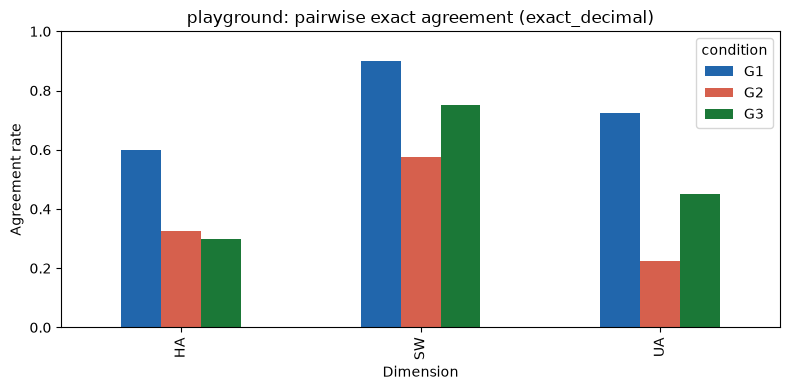

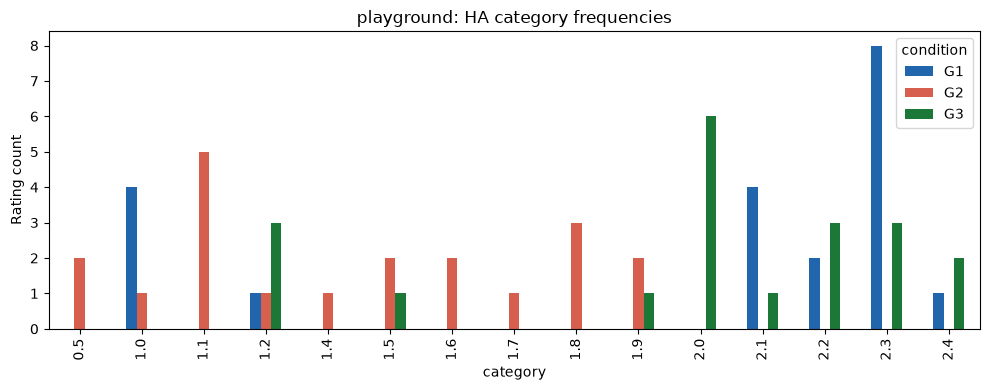

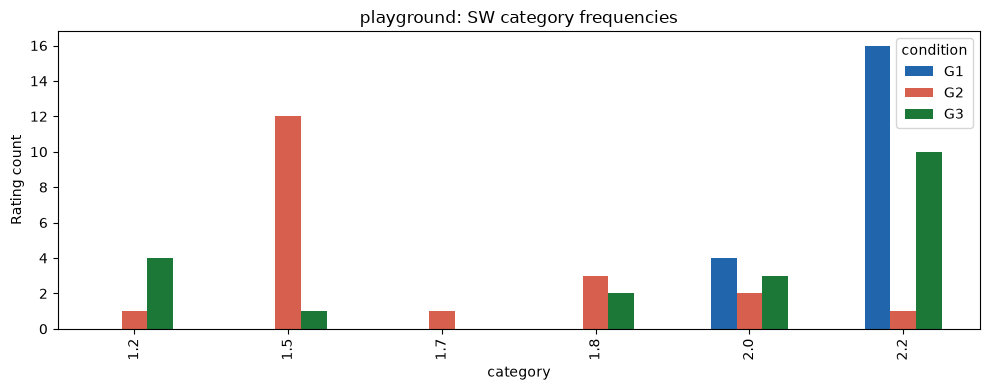

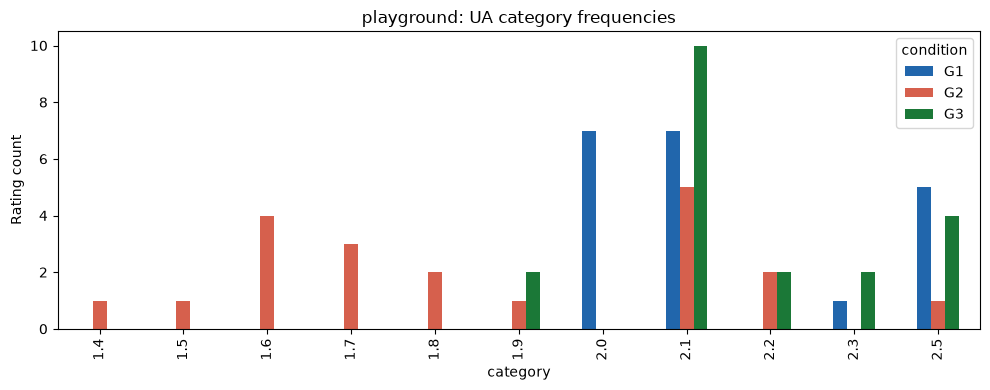

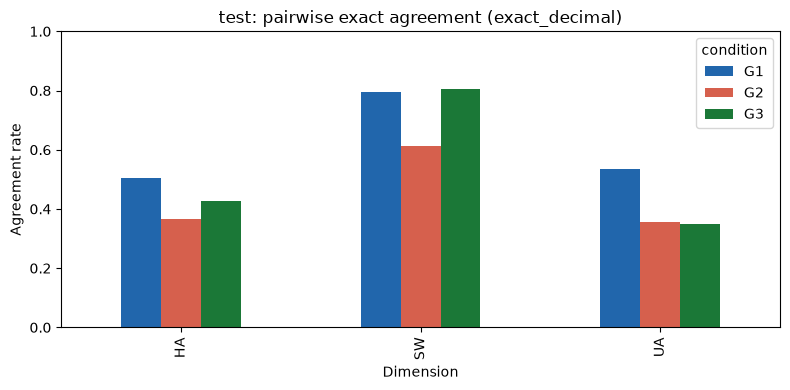

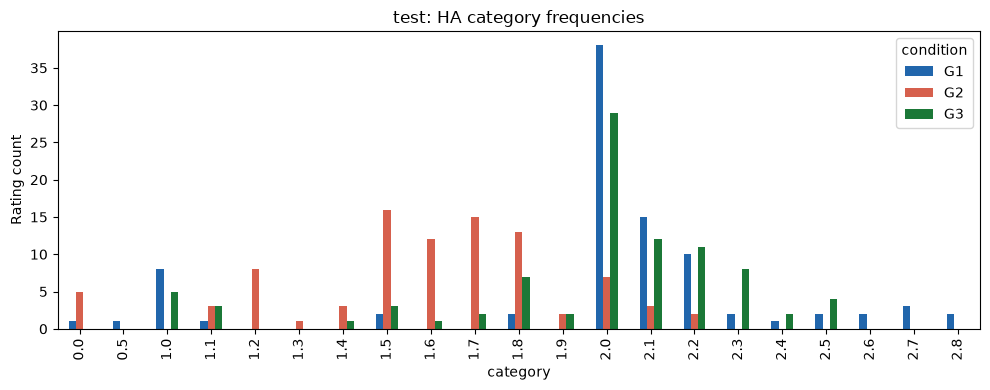

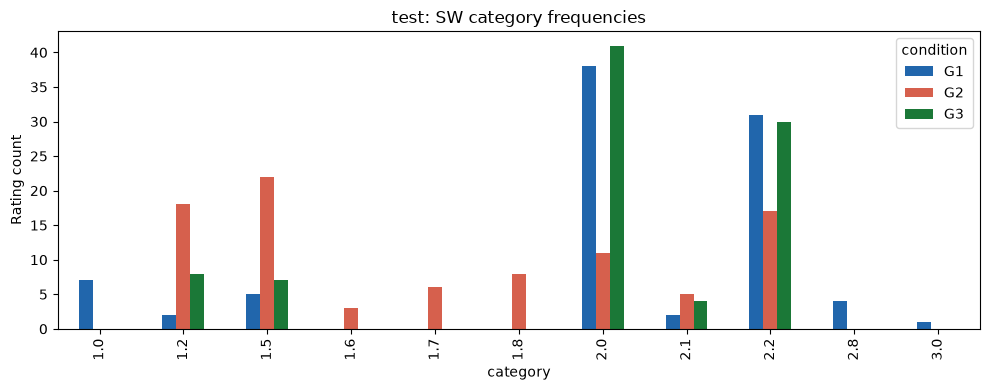

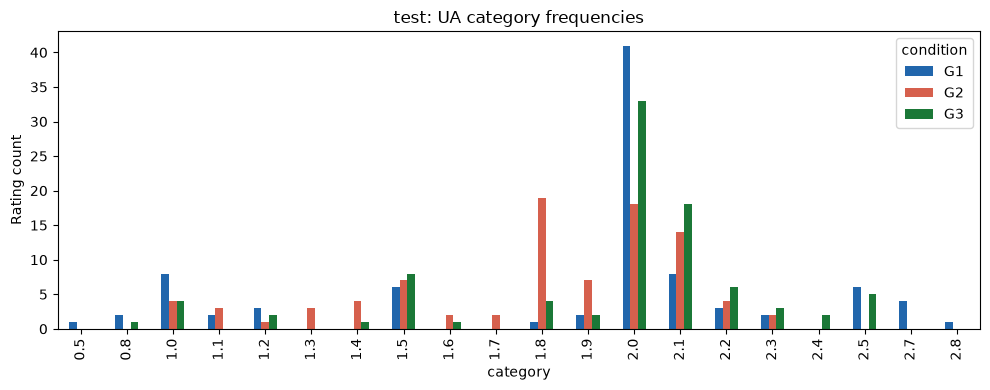

Consistency analysis exported privately; previous results unchanged.


In [16]:
import matplotlib.pyplot as plt

within = consistency_results['within']
for mode in ('playground', 'test'):
    subset = within.loc[within['mode'].eq(mode)]
    if subset.pairwise_exact.notna().any():
        chart = subset.pivot(index='dimension_id', columns='condition', values='pairwise_exact')
        axis = chart.plot.bar(color=['#2166ac', '#d6604d', '#1b7837'], ylim=(0, 1), figsize=(8, 4))
        axis.set_title(f'{mode}: pairwise exact agreement ({CATEGORY_POLICY})')
        axis.set_ylabel('Agreement rate')
        axis.set_xlabel('Dimension')
        plt.tight_layout()
        plt.show()
    frequencies = consistency_results['frequencies'].loc[
        consistency_results['frequencies']['mode'].eq(mode)
    ]
    for dimension, dimension_rows in frequencies.groupby('dimension_id'):
        table = dimension_rows.pivot(index='category', columns='condition', values='count').fillna(0)
        table.plot.bar(figsize=(10, 4), color=['#2166ac', '#d6604d', '#1b7837'])
        plt.title(f'{mode}: {dimension} category frequencies')
        plt.ylabel('Rating count')
        plt.tight_layout()
        plt.show()

if SAVE_ANALYSIS:
    if not EXPERIMENT_DIRECTORY.is_dir() or not (EXPERIMENT_DIRECTORY / 'protocol.json').is_file():
        raise RuntimeError('No frozen saved experiment exists to export.')
    analysis_directory = EXPERIMENT_DIRECTORY / ('analysis-' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
    analysis_directory.mkdir(mode=0o700, exist_ok=False)
    for name, table in {**consistency_results, 'coverage': coverage, 'scores': scores}.items():
        descriptor = os.open(analysis_directory / f'{name}.csv', os.O_CREAT | os.O_EXCL | os.O_WRONLY, 0o600)
        with os.fdopen(descriptor, 'w', encoding='utf-8') as handle:
            table.to_csv(handle, index=False)
    write_private_json(analysis_directory / 'analysis-provenance.json', {
        'protocol_sha256': protocol_hash, 'category_policy': CATEGORY_POLICY,
        'band_mapping': BAND_MAPPING, 'band_mapping_rationale': BAND_MAPPING_RATIONALE,
        'bootstrap_samples': BOOTSTRAP_SAMPLES, 'bootstrap_seed': BOOTSTRAP_SEED,
        'primary_units': 'complete reflections within each condition and dimension',
        'attempt_audit': attempt_audit,
        'source_result_sha256': {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in result_paths},
        'metrics_implementation_sha256': hashlib.sha256(
            (PROJECT_ROOT / 'reflection_assessment_feedback' / 'generation_consistency.py').read_bytes()
        ).hexdigest(),
    })
    print('Consistency analysis exported privately; previous results unchanged.')
else:
    print('Analysis export disabled. No analysis files written.')

## New Direct-GBERT G2: Five-Repeat Consistency Comparison

Compare five fresh G2 generations per reflection with the frozen historical G1/G2/G3 repeat experiment on the same 18 test reflections. The four variants remain separate. Exact-decimal agreement uses the original 0.0-3.0 scores in 0.1 steps without rounding. Corrected canonical author IDs define the exploratory bootstrap clusters. Consistency is repeatability, not assessment accuracy or feedback quality. Historical baselines were generated earlier; this is not a contemporaneous randomized comparison.

Validated 270 historical test generations; new G2 needs 90 independent generations.
Frozen new G2 consistency protocol: /Users/quynguyen/Documents/CodingProjects/prebi_data/generation-consistency-g2-author-disjoint/f73bbd43a95d1b6692049cb88fc1cb106dcddf01c85fea26663016926aa92ca4
Validated new G2 repeat coverage: 90/90; missing=0.
mode           condition dimension_id  documents  complete_documents  missing_ratings  pairwise_exact  unanimous_rate  alpha_nominal alpha_nominal_status  alpha_ordinal alpha_ordinal_status
test       G1 historical           SW         18                  18                0        0.794444        0.666667       0.705772              defined       0.946082              defined
test       G2 historical           SW         18                  18                0        0.611111        0.277778       0.538382              defined       0.908552              defined
test       G3 historical           SW         18                  18                0        0.805

,condition,dimension_id,complete_documents,missing_ratings,pairwise_exact,unanimous_rate,alpha_nominal,alpha_ordinal,alpha_nominal_status,alpha_ordinal_status
0,G1 historical,SW,18,0,0.7944,0.6667,0.7058,0.9461,defined,defined
1,G2 historical,SW,18,0,0.6111,0.2778,0.5384,0.9086,defined,defined
2,G3 historical,SW,18,0,0.8056,0.6111,0.7110,0.8866,defined,defined
3,G2 new direct GBERT,SW,18,0,0.5556,0.3333,0.4645,0.8503,defined,defined
4,G1 historical,UA,18,0,0.5333,0.1111,0.3938,0.8695,defined,defined
5,G2 historical,UA,18,0,0.3556,0.0556,0.2670,0.8227,defined,defined
6,G3 historical,UA,18,0,0.3500,0.0000,0.1997,0.7078,defined,defined
7,G2 new direct GBERT,UA,18,0,0.4222,0.1667,0.3432,0.8883,defined,defined
8,G1 historical,HA,18,0,0.5056,0.2222,0.3643,0.8519,defined,defined
9,G2 historical,HA,18,0,0.3667,0.0556,0.2887,0.7767,defined,defined


pairwise_exact                                                  \
condition     G1 historical G2 historical G2 new direct GBERT G3 historical   
dimension_id                                                                  
HA                   0.5056        0.3667              0.3722        0.4278   
SW                   0.7944        0.6111              0.5556        0.8056   
UA                   0.5333        0.3556              0.4222        0.3500   

             unanimous_rate                                                  \
condition     G1 historical G2 historical G2 new direct GBERT G3 historical   
dimension_id                                                                  
HA                   0.2222        0.0556              0.0556        0.1111   
SW                   0.6667        0.2778              0.3333        0.6111   
UA                   0.1111        0.0556              0.1667        0.0000   

             alpha_nominal                                                  \
condition    G1 historical G2 historical G2 new direct GBERT G3 historical   
dimension_id                                                                 
HA                  0.3643        0.2887              0.3102        0.3267   
SW                  0.7058        0.5384              0.4645        0.7110   
UA                  0.3938        0.2670              0.3432        0.1997   

             alpha_ordinal                                                  
condition    G1 historical G2 historical G2 new direct GBERT G3 historical  
dimension_id                                                                
HA                  0.8519        0.7767              0.8616        0.8849  
SW                  0.9461        0.9086              0.8503        0.8866  
UA                  0.8695        0.8227              0.8883        0.7078

,mode,dimension_id,contrast,documents,authors,difference,lower_95,upper_95,interval_status
0,test,HA,G2 new direct GBERT_minus_G1 historical,18,5,-0.1333,-0.3611,0.1471,exploratory_author_cluster_bootstrap
1,test,HA,G2 new direct GBERT_minus_G2 historical,18,5,0.0056,-0.1889,0.2118,exploratory_author_cluster_bootstrap
2,test,HA,G2 new direct GBERT_minus_G3 historical,18,5,-0.0556,-0.2316,0.1412,exploratory_author_cluster_bootstrap
3,test,SW,G2 new direct GBERT_minus_G1 historical,18,5,-0.2389,-0.3889,-0.0333,exploratory_author_cluster_bootstrap
4,test,SW,G2 new direct GBERT_minus_G2 historical,18,5,-0.0556,-0.2316,0.1333,exploratory_author_cluster_bootstrap
5,test,SW,G2 new direct GBERT_minus_G3 historical,18,5,-0.2500,-0.4316,-0.0133,exploratory_author_cluster_bootstrap
6,test,UA,G2 new direct GBERT_minus_G1 historical,18,5,-0.1111,-0.2833,0.0389,exploratory_author_cluster_bootstrap
7,test,UA,G2 new direct GBERT_minus_G2 historical,18,5,0.0667,-0.0737,0.2579,exploratory_author_cluster_bootstrap
8,test,UA,G2 new direct GBERT_minus_G3 historical,18,5,0.0722,-0.1526,0.3235,exploratory_author_cluster_bootstrap


,mode,dimension_id,left,right,complete_documents,all_pairs_exact
2,test,SW,G1 historical,G2 new direct GBERT,18,0.1578
4,test,SW,G2 historical,G2 new direct GBERT,18,0.4067
5,test,SW,G3 historical,G2 new direct GBERT,18,0.2756
8,test,UA,G1 historical,G2 new direct GBERT,18,0.1356
10,test,UA,G2 historical,G2 new direct GBERT,18,0.2311
11,test,UA,G3 historical,G2 new direct GBERT,18,0.2156
14,test,HA,G1 historical,G2 new direct GBERT,18,0.0711
16,test,HA,G2 historical,G2 new direct GBERT,18,0.1889
17,test,HA,G3 historical,G2 new direct GBERT,18,0.0778


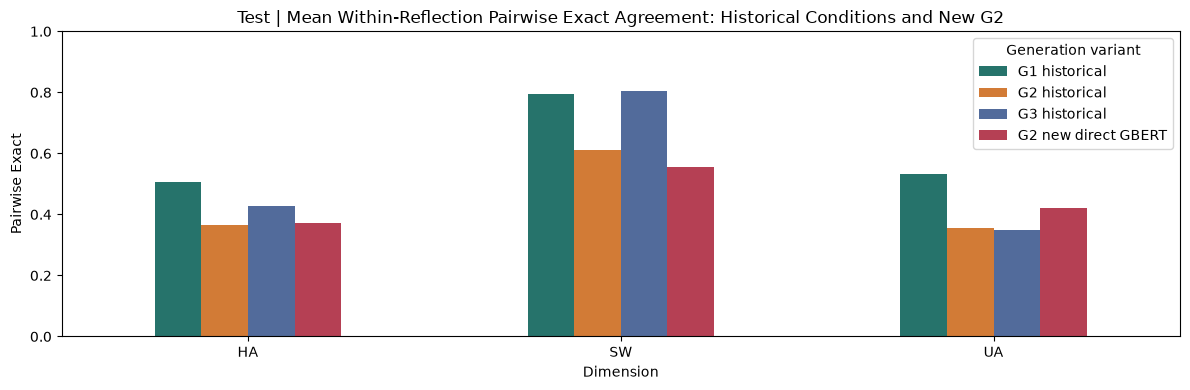

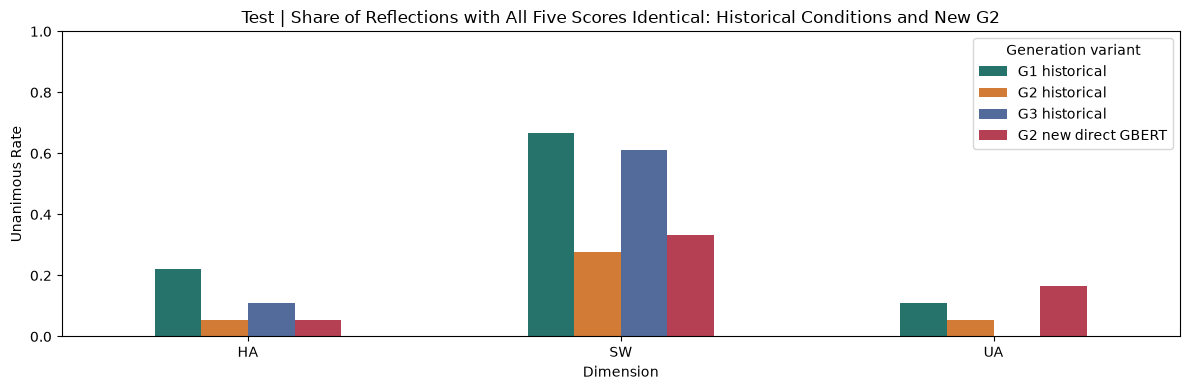

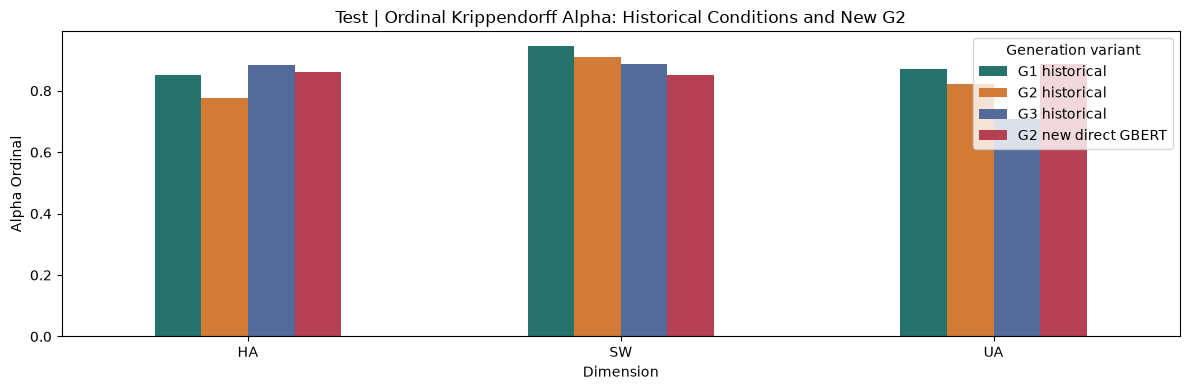

Aggregate comparison saved: /Users/quynguyen/Documents/CodingProjects/prebi_v1/artifacts/g2-generation-consistency/f73bbd43a95d1b6692049cb88fc1cb106dcddf01c85fea26663016926aa92ca4
No provider calls were made by this analysis section.


In [2]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import Markdown, display

from scripts.rerun_g2_generation_consistency import (
    NEW_VARIANT,
    VARIANTS,
    analyze as analyze_new_g2_consistency,
    prepare as prepare_new_g2_consistency,
    validate_new_record,
 )

display(Markdown('## New Direct-GBERT G2: Five-Repeat Consistency Comparison'))
display(Markdown(
    'Compare five fresh G2 generations per reflection with the frozen historical '
    'G1/G2/G3 repeat experiment on the same 18 test reflections. '
    'The four variants remain separate. Exact-decimal agreement uses the original '
    '0.0-3.0 scores in 0.1 steps without rounding. '
    'Corrected canonical author IDs define the exploratory bootstrap clusters. '
    'Consistency is repeatability, not assessment accuracy or feedback quality. '
    'Historical baselines were generated earlier; this is not a contemporaneous randomized comparison.'
 ))
consistency_project_root = Path.cwd().resolve()
if consistency_project_root.name != 'prebi_v1':
    raise RuntimeError('Run this section from the prebi_v1 project root.')
load_dotenv(consistency_project_root / '.env', override=False)
new_consistency_context = prepare_new_g2_consistency()
new_consistency_records = []
new_consistency_missing = []
for document_id in new_consistency_context['units'].document_id:
    for repetition in range(1, 6):
        result_path = (
            new_consistency_context['directory'] / 'results'
            / f'document-{document_id}-rep-{repetition}.json'
        )
        if not result_path.is_file():
            new_consistency_missing.append((document_id, repetition))
            continue
        import json
        record = json.loads(result_path.read_text(encoding='utf-8'))
        validate_new_record(record, new_consistency_context, document_id, repetition)
        new_consistency_records.append(record)
print(f'Validated new G2 repeat coverage: {len(new_consistency_records)}/90; missing={len(new_consistency_missing)}.')

if new_consistency_missing:
    print('Comparison withheld until all 18 reflections have five valid independent repetitions.')
else:
    new_consistency_report_directory = analyze_new_g2_consistency(new_consistency_context)
    new_consistency_within = pd.read_csv(new_consistency_report_directory / 'within.csv')
    new_consistency_between = pd.read_csv(new_consistency_report_directory / 'between.csv')
    new_consistency_differences = pd.read_csv(new_consistency_report_directory / 'paired-differences.csv')
    metric_columns = [
        'pairwise_exact', 'unanimous_rate', 'alpha_nominal', 'alpha_ordinal',
    ]
    display(new_consistency_within[[
        'condition', 'dimension_id', 'complete_documents', 'missing_ratings',
        *metric_columns, 'alpha_nominal_status', 'alpha_ordinal_status',
    ]].round(4))
    display(new_consistency_within.pivot(
        index='dimension_id', columns='condition', values=metric_columns,
    ).round(4))
    display(new_consistency_differences.round(4))
    display(new_consistency_between.loc[
        new_consistency_between['left'].eq(NEW_VARIANT)
        | new_consistency_between['right'].eq(NEW_VARIANT)
    ].round(4))

    consistency_colors = ['#26736b', '#d27b36', '#526b9b', '#b54054']
    for metric, title in (
        ('pairwise_exact', 'Mean Within-Reflection Pairwise Exact Agreement'),
        ('unanimous_rate', 'Share of Reflections with All Five Scores Identical'),
        ('alpha_ordinal', 'Ordinal Krippendorff Alpha'),
    ):
        chart = new_consistency_within.pivot(
            index='dimension_id', columns='condition', values=metric,
        ).reindex(columns=list(VARIANTS))
        axis = chart.plot(kind='bar', rot=0, figsize=(12, 4), color=consistency_colors)
        axis.set_title(f'Test | {title}: Historical Conditions and New G2')
        axis.set_ylabel(metric.replace('_', ' ').title())
        axis.set_xlabel('Dimension')
        if metric != 'alpha_ordinal':
            axis.set_ylim(0, 1)
        axis.legend(title='Generation variant')
        plt.tight_layout()
        plt.show()
    print('Aggregate comparison saved:', new_consistency_report_directory)
    print('No provider calls were made by this analysis section.')

In [18]:
def recover_missing_g2():
    if not (RUN_GENERATION and APPROVE_EXTERNAL_PROCESSING and APPROVE_CATEGORY_POLICY and APPROVE_G2_PROVENANCE and PROTOCOL_FROZEN_FOR_TEST):
        raise RuntimeError('The frozen test protocol and all processing approvals are required.')
    if canonical_hash(protocol) != protocol_hash or json.loads((EXPERIMENT_DIRECTORY / 'protocol.json').read_text()) != protocol:
        raise ValueError('The frozen protocol manifest changed.')
    if MODES_TO_RUN != ('test',) or REPETITIONS != 5 or CATEGORY_POLICY != 'exact_decimal':
        raise RuntimeError('Recovery is limited to the approved five-repetition test protocol.')

    expected_test_keys = {
        (document_id, condition, repetition)
        for document_id in cohort_units.loc[cohort_units['mode'].eq('test'), 'document_id']
        for condition in ('G1', 'G2', 'G3')
        for repetition in range(1, REPETITIONS + 1)
    }
    saved_test_keys = set()
    for saved_path in (EXPERIMENT_DIRECTORY / 'results').glob('*.json'):
        saved_record = json.loads(saved_path.read_text())
        saved_key = (saved_record.get('document_id'), saved_record.get('condition'), saved_record.get('repetition'))
        if saved_key in expected_test_keys:
            validate_saved_record(saved_record, *saved_key)
            saved_test_keys.add(saved_key)
    missing_test_keys = expected_test_keys - saved_test_keys
    if not missing_test_keys:
        print('All expected test results are already saved; no provider call was made.')
        return
    if len(missing_test_keys) != 1:
        raise RuntimeError(f'Expected exactly one missing test result; found {len(missing_test_keys)}.')
    recovery_document_id, recovery_condition, recovery_repetition = next(iter(missing_test_keys))
    if recovery_condition != 'G2':
        raise RuntimeError('The sole missing test result is not a G2 call.')

    recovery_key = repetition_key(recovery_document_id, recovery_condition, recovery_repetition)
    recovery_directory = EXPERIMENT_DIRECTORY / 'attempts' / recovery_key
    prior_failures = [
        json.loads(failure_path.read_text())
        for failure_path in recovery_directory.glob('failed-*.json')
    ]
    if len(prior_failures) != MAX_ATTEMPTS or not all(
        failure.get('error_type') == 'GoogleRateLimitError' for failure in prior_failures
    ):
        raise RuntimeError('Recovery requires exactly the three recorded quota failures.')
    if not all('429' in failure.get('message', '') or 'RESOURCE_EXHAUSTED' in failure.get('message', '')
               for failure in prior_failures):
        raise RuntimeError('Prior failures do not all identify provider quota exhaustion.')

    recovery_result_path = EXPERIMENT_DIRECTORY / 'results' / f'{recovery_key}.json'
    if recovery_result_path.exists():
        raise RuntimeError('The missing result appeared before recovery; nothing was called.')
    recovery_started = list(recovery_directory.glob('started-*.json'))
    recovery_attempt = max(
        (int(path.stem.split('-')[-1]) for path in recovery_started), default=0
    ) + 1
    if recovery_attempt != MAX_ATTEMPTS + 1:
        raise RuntimeError('Expected the single recovery attempt to follow the original attempt limit.')

    recovery_lock_fd = os.open(EXPERIMENT_DIRECTORY / '.runner.lock', os.O_CREAT | os.O_RDWR, 0o600)
    try:
        fcntl.flock(recovery_lock_fd, fcntl.LOCK_EX | fcntl.LOCK_NB)
    except BlockingIOError as error:
        os.close(recovery_lock_fd)
        raise RuntimeError('Another generation runner currently holds the experiment lock.') from error
    try:
        recovery_request = GenerationRequest.model_validate(
            request_snapshots[(recovery_document_id, recovery_condition)]
        )
        recovery_base_record = {
            'protocol_sha256': protocol_hash,
            'document_id': recovery_document_id,
            'condition': recovery_condition,
            'repetition': recovery_repetition,
            'request_sha256': protocol['request_hashes'][f'{recovery_document_id}:{recovery_condition}'],
            'prompt_sha256': protocol['prompt_hashes'][f'{recovery_document_id}:{recovery_condition}'],
        }
        recovery_attempt_record = {
            **recovery_base_record,
            'attempt': recovery_attempt,
            'recovery_beyond_protocol_attempt_limit': True,
            'attempt_id': str(uuid4()),
            'started_at': datetime.now(timezone.utc).isoformat(),
        }
        write_private_json(recovery_directory / f'started-{recovery_attempt}.json', recovery_attempt_record)
        reserve_request_slot(
            PROTECTED_ROOT / '.rate_limits' / 'gemini.state',
            GENERATION_CONFIG['minimum_request_interval_seconds'],
        )
        try:
            recovery_run = runner.generate(recovery_request, repetition=recovery_repetition)
            recovery_payload = {
                **recovery_base_record,
                'attempt': recovery_attempt,
                'recovery_beyond_protocol_attempt_limit': True,
                'run': asdict(recovery_run),
                'output': recovery_run.output.model_dump(mode='json'),
            }
            recovery_payload['run']['output'] = recovery_payload['output']
            validate_saved_record(
                recovery_payload, recovery_document_id, recovery_condition, recovery_repetition
            )
        except Exception as recovery_error:
            write_private_json(recovery_directory / f'failed-{recovery_attempt}.json', {
                **recovery_attempt_record,
                'finished_at': datetime.now(timezone.utc).isoformat(),
                'error_type': type(recovery_error).__name__,
                'message': str(recovery_error),
            })
            print(f'The single recovery attempt failed ({type(recovery_error).__name__}); details remain protected.')
            raise
        write_private_json(recovery_result_path, recovery_payload)
        write_private_json(recovery_directory / f'succeeded-{recovery_attempt}.json', {
            **recovery_attempt_record,
            'finished_at': datetime.now(timezone.utc).isoformat(),
        })
        print('The single missing G2 result was saved; no other provider calls were made.')
    finally:
        fcntl.flock(recovery_lock_fd, fcntl.LOCK_UN)
        os.close(recovery_lock_fd)


recover_missing_g2()

All expected test results are already saved; no provider call was made.
